# Decisive Probability Distributions

In this activity, you’ll use the Alpaca API to gather pricing information for six stocks. Then, you’ll use this information to plot probability distributions for the daily returns of the stocks. Finally, you’ll determine the most and the least volatile stocks.
Instructions:

1. Create an environment file (`.env`) in the root of the `Unsolved` folder. This file will hold your Alpaca API and secret keys.

2. Load the Alpaca API and secret keys into `decisive_probability_distributions.ipynb`, and set the values equal to variables of the same name.

3. Create the Alpaca API `REST` object by calling the Alpaca `tradeapi.REST` function and setting `alpaca_api_key`, `alpaca_secret_key`, and `api_version`.

4. Use the Alpaca SDK to make an API call that gets one year of daily stock information ( 2019-05-01 to 2020-05-01) for the following stock tickers:

    - `SPY` (SPDR S&P 500 ETF Trust)

    - `LUV` (Southwest Airlines)

    - `DIS` (Disney) 

    - `AAPL` (Apple)

    - `SBUX` (Starbucks)

    - `ZM` (Zoom)

> **Hint** Remember to set the tickers, time frame, start and end dates (‘2019-05-01’ and ‘2020-05-01’) and the number of rows returned. Then use the Alpaca `get_bars` function to make the API call. Be sure to set the `df` property at the end of the `get_bars` function so that the API response is returned as a DataFrame.

5. Create a new DataFrame that holds the closing prices of each stock.

6. Generate a daily returns DataFrame that’s based on the closing prices of each stock.

7. Generate the summary statistics for the daily returns DataFrame. This provides your first review of the distribution information for your stocks.

8. Visualize the distribution of the daily returns DataFrame by creating a histogram plot and a density plot.

> **Hint** Generate only two plots. Both the histogram and the density plot will show the data for all six stocks.


References:

[Alpaca API Docs](https://alpaca.markets/docs/api-documentation/)

[Pandas Histogram plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

[Pandas Density plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.density.html)

## Import the required libraries and dependencies

In [2]:
# Import the required libraries and dependencies
import os
import requests
import pandas as pd
from dotenv import load_dotenv
from alpaca.trading.client import TradingClient

## Step 1: Create your `.env` file at the root of your Unsolved folder. It should include your Alpaca API and secret keys. 

## Step 2: Load the Alpaca API and secret keys into `decisive_probability_distributions.ipynb`, and set the values equal to variables of the same name.

* Load the environment variable by calling the `load_dotenv()` function.
* Set the value of the variables `alpaca_api_key` and `alpaca_secret_key` equal to their respective environment variables. 
* Confirm the variables are available by checking the `type` of each. 

In [3]:
# Load the environment variables by calling the load_dotenv function
load_dotenv()

True

In [5]:
# Set Alpaca API key and secret by calling the os.getenv function and referencing the environment variable names
# Set each environment variable to a notebook variable of the same name
alpaca_api_key = os.getenv("ALPACA_API")
alpaca_secret_key = os.getenv("ALPACA_SECRET")

# Check the values were imported correctly by evaluating the type of each
display(type(alpaca_api_key))
display(type(alpaca_secret_key))

str

str

## Step 3: Create the Alpaca API `REST` object by calling the Alpaca `tradeapi.REST` function and setting `alpaca_api_key`, `alpaca_secret_key`, and `api_version`.

In [6]:
# Create your Alpaca API REST object by calling Alpaca's tradeapi.REST function
# Set the parameters to your alpaca_api_key, alpaca_secret_key and api_version="v2" 
alpaca = tradeapi.REST(
    alpaca_api_key,
    alpaca_secret_key,
    api_version="v2")

NameError: name 'tradeapi' is not defined

In [7]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime

data_client = StockHistoricalDataClient(alpaca_api_key, alpaca_secret_key)

## Step 4: Use the Alpaca SDK to make an API call that gets one year of daily stock information ( 2019-05-01 to 2020-05-01) for the following stock tickers: SPY, LUV, DIS, AAPL, SBUX, and ZM. 

* Create the list for the required `tickers`
* Set the values for `start_date` and `end_date` using the `pd.Timestamp` function. The dates should be 2019-05-01 through 2020-05-01.
* Set the `timeframe` value to 1 day.
* Create the `portfolio_prices_df` DataFrame by setting it equal to the `alpaca.get_bars` function. 

In [8]:
# Create the list for the required tickers
tickers = ["SPY", "LUV", "DIS", "AAPL", "SBUX", "ZM"]

In [9]:
# Set the values for start_date and end_date using the pd.Timestamp function
# The start and end data should be 2019-05-01 to 2020-05-01
# Set the parameter tz to "America/New_York", 
# Set this all to the ISO format by calling the isoformat function 
start_date = pd.Timestamp("2019-05-01", tz="America/New_York").isoformat()
end_date = pd.Timestamp("2020-05-01", tz="America/New_York").isoformat()


In [10]:
# Set timeframe to one day (1Day)
timeframe = "1Day"

In [11]:
# Use the Alpaca get_bars function to gather the price information for each ticker
# Include the function parameters: tickers, timeframe, start, end, and limit
# Be sure to call the df property to ensure that the returned information is set as a DataFrame
prices_df = alpaca.get_bars(
    tickers,
    timeframe,
    start=start_date,
    end=end_date
).df

# Review the first five rows of the resulting DataFrame 
prices_df.head()

NameError: name 'alpaca' is not defined

In [22]:
request = StockBarsRequest(
    symbol_or_symbols=tickers,
    timeframe=TimeFrame.Day,
    start=start_date,
    end=end_date
)

prices_df = data_client.get_stock_bars(request).df
prices_df.head()

open      high      low   close  \
symbol timestamp                                                      
AAPL   2019-05-01 04:00:00+00:00  209.88  215.3100  209.230  210.52   
       2019-05-02 04:00:00+00:00  209.84  212.6500  208.130  209.15   
       2019-05-03 04:00:00+00:00  210.89  211.8400  210.230  211.75   
       2019-05-06 04:00:00+00:00  204.29  208.8400  203.500  208.48   
       2019-05-07 04:00:00+00:00  205.88  207.4175  200.825  202.86   

                                      volume  trade_count        vwap  
symbol timestamp                                                       
AAPL   2019-05-01 04:00:00+00:00  68138465.0     441448.0  212.623902  
       2019-05-02 04:00:00+00:00  33437264.0     233408.0  210.178582  
       2019-05-03 04:00:00+00:00  23050067.0     148241.0  211.196606  
       2019-05-06 04:00:00+00:00  34940726.0     236170.0  207.357948  
       2019-05-07 04:00:00+00:00  41821244.0     294535.0  203.526700

In [23]:
prices_df = prices_df.reset_index()
prices_df.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,AAPL,2019-05-01 04:00:00+00:00,209.88,215.3100,209.230,210.52,68138465.0,441448.0,212.623902
1,AAPL,2019-05-02 04:00:00+00:00,209.84,212.6500,208.130,209.15,33437264.0,233408.0,210.178582
2,AAPL,2019-05-03 04:00:00+00:00,210.89,211.8400,210.230,211.75,23050067.0,148241.0,211.196606
3,AAPL,2019-05-06 04:00:00+00:00,204.29,208.8400,203.500,208.48,34940726.0,236170.0,207.357948
4,AAPL,2019-05-07 04:00:00+00:00,205.88,207.4175,200.825,202.86,41821244.0,294535.0,203.526700


In [26]:
SPY = prices_df[prices_df['symbol']=='SPY'].drop('symbol', axis=1).set_index('timestamp')
LUV = prices_df[prices_df['symbol']=='LUV'].drop('symbol', axis=1).set_index('timestamp')
DIS = prices_df[prices_df['symbol']=='DIS'].drop('symbol', axis=1).set_index('timestamp')
AAPL = prices_df[prices_df['symbol']=='AAPL'].drop('symbol', axis=1).set_index('timestamp')
SBUX = prices_df[prices_df['symbol']=='SBUX'].drop('symbol', axis=1).set_index('timestamp')
ZM = prices_df[prices_df['symbol']=='ZM'].drop('symbol', axis=1).set_index('timestamp')


In [27]:
prices_df2 = pd.concat([SPY, LUV, DIS, AAPL, SBUX, ZM], axis=1, keys=["SPY", "LUV", "DIS", "AAPL", "SBUX", "ZM"])

# Display sample data
prices_df2.head()

SPY                                         \
                             open    high       low   close       volume   
timestamp                                                                  
2019-05-01 04:00:00+00:00  294.72  294.95  291.8000  291.82   72689383.0   
2019-05-02 04:00:00+00:00  291.68  292.70  289.5200  291.13   66830633.0   
2019-05-03 04:00:00+00:00  292.82  294.34  291.2998  293.98   57828940.0   
2019-05-06 04:00:00+00:00  289.25  293.31  288.9000  292.83  117885315.0   
2019-05-07 04:00:00+00:00  290.15  290.81  285.8100  288.05  148103972.0   

                                                     LUV                 ...  \
                          trade_count        vwap   open   high     low  ...   
timestamp                                                                ...   
2019-05-01 04:00:00+00:00    337375.0  293.665913  54.60  54.61  53.855  ...   
2019-05-02 04:00:00+00:00    342562.0  291.065996  53.99  54.49  53.360  ...   
2019-05-03 04:00:00+00:00    249403.0  293.468466  53.52  53.93  53.285  ...   
2019-05-06 04:00:00+00:00    390956.0  291.916975  52.80  53.61  52.720  ...   
2019-05-07 04:00:00+00:00    618591.0  287.984316  53.04  53.12  51.450  ...   

                                SBUX                            ZM         \
                              volume trade_count       vwap   open   high   
timestamp                                                                   
2019-05-01 04:00:00+00:00  7175353.0     50560.0  77.677223  72.72  76.95   
2019-05-02 04:00:00+00:00  6636948.0     50732.0  77.276452  72.75  75.89   
2019-05-03 04:00:00+00:00  5362489.0     39844.0  78.001622  75.00  80.25   
2019-05-06 04:00:00+00:00  6042660.0     46779.0  77.743668  75.01  80.79   
2019-05-07 04:00:00+00:00  8851747.0     71208.0  78.047889  77.85  78.05   

                                                                             
                               low  close     volume trade_count       vwap  
timestamp                                                                    
2019-05-01 04:00:00+00:00  70.8159  72.76  3330772.0     24224.0  74.236656  
2019-05-02 04:00:00+00:00  69.6912  75.50  2574604.0     18049.0  72.565865  
2019-05-03 04:00:00+00:00  75.0000  79.18  2621517.0     20641.0  78.266017  
2019-05-06 04:00:00+00:00  74.5000  78.24  2116687.0     20421.0  78.032820  
2019-05-07 04:00:00+00:00  73.2500  73.33  2002382.0     19519.0  75.593550  

[5 rows x 42 columns]

## Step 5: Create a new DataFrame that holds the closing prices of each stock.

1. Create a `closing_prices_df` DataFrame.
2. Using a for-loop, for every `ticker` in the `tickers` list, select the `close` price for each ticker in the `prices_df` Dataframe. That expression will be set equal to  the new `closing_prices_df` for the same `ticker`.
3. For the new closing_prices_df DataFrame, keep only the date component (drop the time component).
4. View the `closing_prices_df` DataFrame. 

In [28]:
# Create an empty DataFrame for holding the closing prices
closing_prices_df = pd.DataFrame()

# Using a for loop, for every ticker in the tickers list, 
# Select the close price for each ticker in the prices_df Dataframe
# That will be set equal to closing_prices_df for the same ticker value
for ticker in tickers:
    closing_prices_df[ticker] = prices_df2[ticker]["close"]

# For the new closing_prices_df DataFrame, keep only the date component
closing_prices_df.index = closing_prices_df.index.date

# View the first and last five rows of the closing_prices_df DataFrame
display(closing_prices_df.head())
display(closing_prices_df.tail())

,SPY,LUV,DIS,AAPL,SBUX,ZM
2019-05-01,291.82,53.90,136.38,210.52,77.52,72.76
2019-05-02,291.13,53.37,134.14,209.15,77.47,75.50
2019-05-03,293.98,53.62,134.33,211.75,78.05,79.18
2019-05-06,292.83,53.48,135.00,208.48,78.06,78.24
2019-05-07,288.05,52.21,133.44,202.86,77.96,73.33


,SPY,LUV,DIS,AAPL,SBUX,ZM
2020-04-27,287.10,29.11,106.06,283.170,77.740,164.600
2020-04-28,285.69,29.69,106.21,278.580,78.690,156.720
2020-04-29,293.15,30.97,112.25,287.730,76.860,146.561
2020-04-30,290.63,31.25,108.15,293.949,76.719,135.170
2020-05-01,282.83,29.23,105.50,289.070,73.785,138.560


## Step 6: Generate a daily returns DataFrame that’s based on the closing prices of each stock.

In [29]:
# Compute daily returns of the closing_prices_df DataFrame using the pct_change function 
# Be sure to drop the first row of NaN values
daily_returns_df = closing_prices_df.pct_change().dropna()

# Review the first and last five rows of the daily_returns_df DataFrame
display(daily_returns_df.head())
display(daily_returns_df.tail())


,SPY,LUV,DIS,AAPL,SBUX,ZM
2019-05-02,-0.002364,-0.009833,-0.016425,-0.006508,-0.000645,0.037658
2019-05-03,0.009789,0.004684,0.001416,0.012431,0.007487,0.048742
2019-05-06,-0.003912,-0.002611,0.004988,-0.015443,0.000128,-0.011872
2019-05-07,-0.016323,-0.023747,-0.011556,-0.026957,-0.001281,-0.062756
2019-05-08,-0.001111,0.003831,0.011616,0.000197,0.001154,0.059321


,SPY,LUV,DIS,AAPL,SBUX,ZM
2020-04-27,0.014882,-0.007501,0.048127,0.000707,0.028579,0.036524
2020-04-28,-0.004911,0.019924,0.001414,-0.016209,0.012220,-0.047874
2020-04-29,0.026112,0.043112,0.056868,0.032845,-0.023256,-0.064823
2020-04-30,-0.008596,0.009041,-0.036526,0.021614,-0.001835,-0.077722
2020-05-01,-0.026838,-0.064640,-0.024503,-0.016598,-0.038243,0.025080


## Step 7: Generate the summary statistics for the daily returns DataFrame. This provides your first review of the distribution information for your stocks.

In [30]:
# Using the Pandas describe function, generate summary statistics
# for each of the tickers in the daily_returns_df DataFrame
daily_returns_df.describe()

,SPY,LUV,DIS,AAPL,SBUX,ZM
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,0.000058,-0.001992,-0.000646,0.001582,0.000161,0.003493
std,0.018986,0.028899,0.027257,0.025603,0.026738,0.043885
min,-0.107828,-0.151094,-0.129846,-0.128647,-0.162042,-0.152795
25%,-0.004727,-0.009047,-0.009820,-0.007907,-0.010148,-0.017709
50%,0.000830,-0.000189,0.000099,0.000707,0.000713,0.000965
75%,0.006934,0.009041,0.008487,0.013432,0.009194,0.021675
max,0.086761,0.144441,0.153043,0.119808,0.147303,0.222214


## Step 8. Visualize the distribution of the daily returns DataFrame by creating a histogram plot and a density plot.

<Axes: title={'center': 'Daily Returns Histogram'}, ylabel='Frequency'>

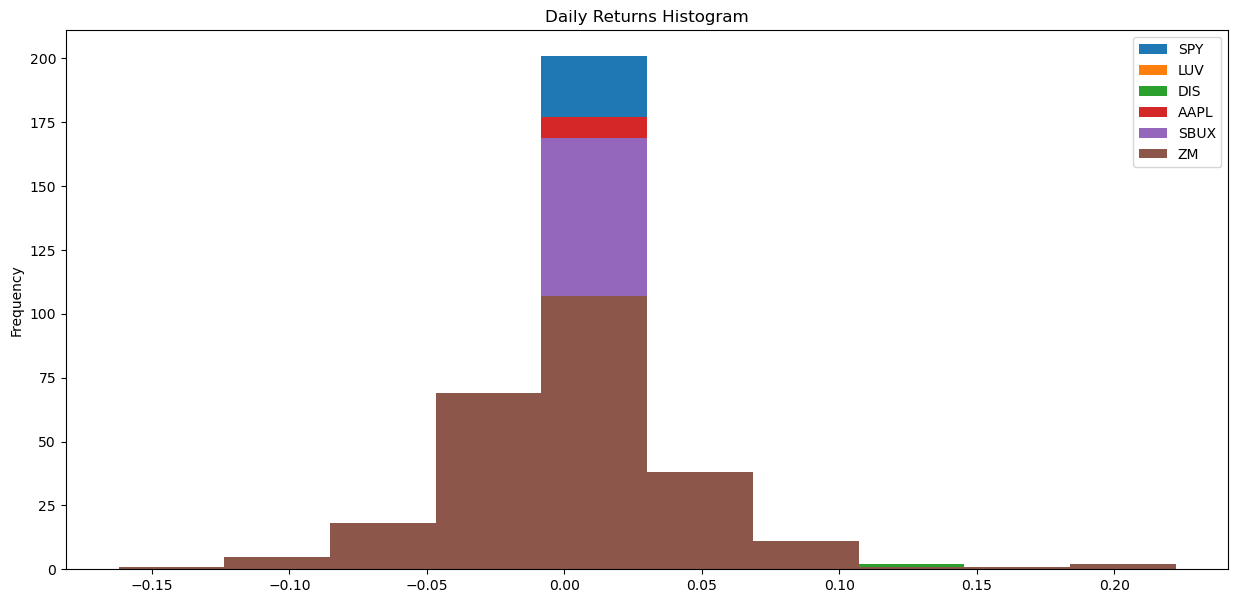

In [31]:
# Visualize the distribution of daily returns across all stocks using a histogram plot
# Give the plot a title and adjust the figure size
daily_returns_df.plot(
    kind="hist",  
    figsize=(15,7),
    title="Daily Returns Histogram"
)

<Axes: title={'center': 'Daily Returns Density Plot'}, ylabel='Density'>

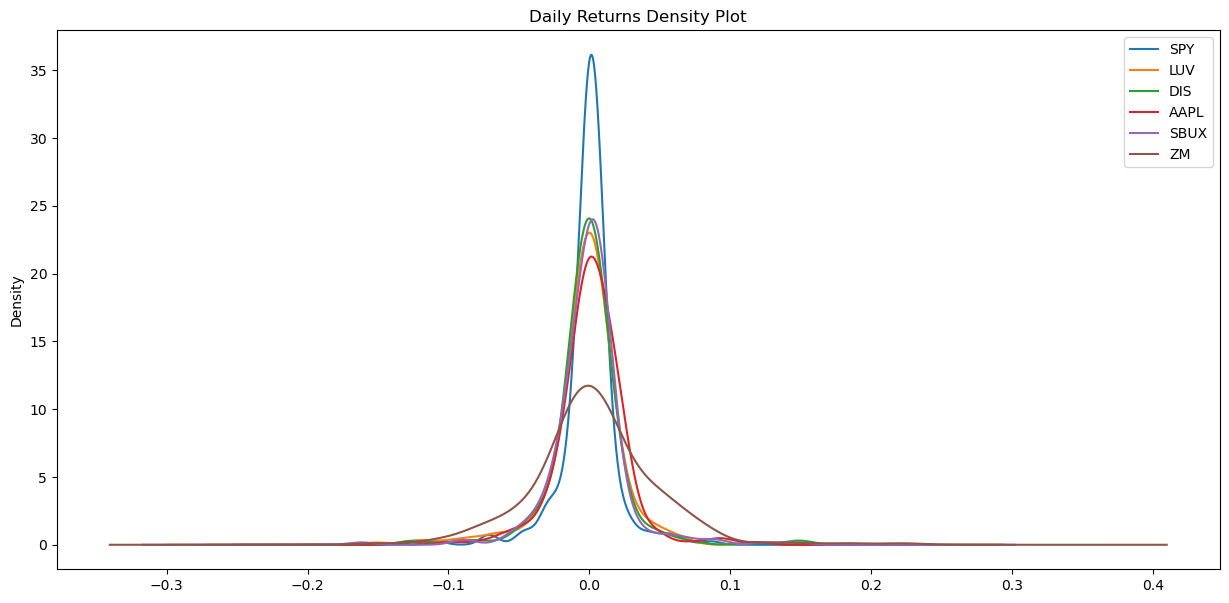

In [33]:
# Visualize the distribution of daily returns across all stocks using a density plot
# Give the plot a title and adjust the figure size
daily_returns_df.plot.density(
    figsize=(15,7), 
    title="Daily Returns Density Plot"
)

## Reflect on the following question:

**Question:** After analyzing the summary statistics, histogram, and density plot for the SPY, LUV, DIS, AAPL, SBUX, and ZM stocks, which do you think is the most volatile stock based on the daily return data? Which is the least volatile?
    
**Answer:** The most volatile stock is ZM (Zoom Video Communications), an technology communications stock,  and the least volatile is SPY (SPDR S&P 500 ETF Trust). SPY represents the S&P 500 market index. Due to the broad array of stocks that make up the S&P 500 index, its daily return performance tends to be, over time, less volatile than the individual stocks that comprise the index. 